<a href="https://colab.research.google.com/github/Nounsidev/PyTorch_Learning/blob/main/5_ComputerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [24]:
##1. GETTING A DATASET
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)


In [25]:
len(train_data), len(test_data)

(60000, 10000)

In [26]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [27]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

1.2 VISUALIZING DATA


Image Shape: torch.Size([1, 28, 28])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

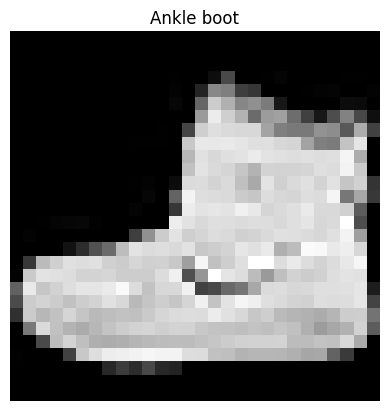

In [28]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

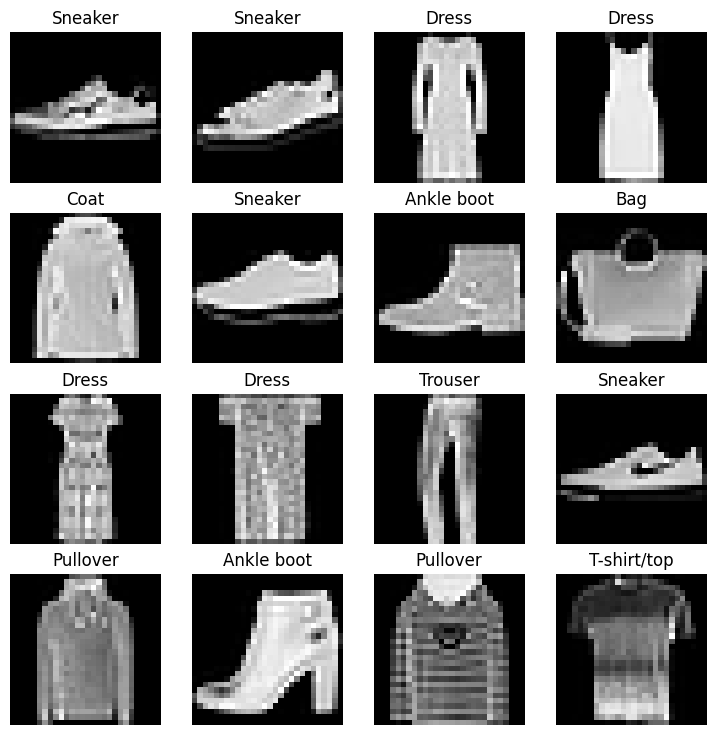

In [29]:
#Plot more images
torch.manual_seed(38)

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols +1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.title(class_names[label])
  plt.imshow(image.squeeze(), cmap="gray")
  plt.axis(False)

2. PREPARE DATA LOADER

In [30]:
#Split into 32-size batch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)


train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ce5a16f3890>,
 <torch.utils.data.dataloader.DataLoader at 0x7ce5a3fe3bb0>)

In [31]:
print(f"Dataloaders: {train_dataloader, test_dataloader}")
#

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7ce5a16f3890>, <torch.utils.data.dataloader.DataLoader object at 0x7ce5a3fe3bb0>)


In [32]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image Shape: torch.Size([1, 28, 28])
Label: 8, label shape: torch.Size([])


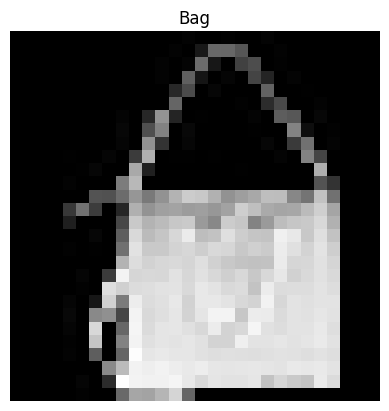

In [33]:
#torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

print(f"Image Shape: {image.shape}")
print(f"Label: {label}, label shape: {label.shape}")


3. BUILD A BASELINE MODEL

In [34]:
#Create a flatten layer
flatter_model = nn.Flatten()

#Get a single sample
x = train_features_batch[0]

#Flatten the sample
output = flatter_model(x) # perform a forward pass

print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [35]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)


In [36]:
torch.manual_seed(38)

#Setup model with input parameters
modelV0 = FashionMNISTModelV1(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")
modelV0

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [37]:
dummy_x = torch.rand([1, 1, 28, 28])
modelV0(dummy_x)

tensor([[ 0.4329,  0.1027, -0.3434, -0.0773,  0.0406,  0.0514,  0.7181,  0.1866,
          0.0195,  0.4578]], grad_fn=<AddmmBackward0>)

In [38]:
# 3.1 SETUP LOSS, OPTIMIZER AND EVALUATION METRICS
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


helper_functions.py already exists, skipping download


In [39]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=modelV0.parameters(), lr=0.01)


In [40]:
# 3.2 EXPERIMENTING
from timeit import default_timer as Timer
def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [41]:
start_time = Timer()

#Code
end_time = Timer()

print_train_time(start_time, end_time, device= "cpu")


Train time on cpu: 0.000 seconds


7.560299997066977e-05

In [42]:
# 3.3 Creating a training loop and training a model on batches of data
from tqdm.auto import tqdm

#Set the seed and timer
torch.manual_seed(38)
train_time_start_on_cpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_loss = 0

  for batch, (X, y) in enumerate(train_dataloader):
    modelV0.train()

    #1. Forward Pass
    y_pred = modelV0(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss

    #2. Optimizer Zero Grad
    optimizer.zero_grad()

    #3. Loss Backward
    loss.backward()

    #4. Optimizer Step
    optimizer.step()


    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  test_loss, test_acc = 0, 0
  modelV0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      test_pred = modelV0(X_test)
      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim = 1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

  train_timer_end_on_cpu = Timer()
  total_train_time_modelV0 = print_train_time(start=train_time_start_on_cpu,
                                              end=train_timer_end_on_cpu,
                                              device=str(next(modelV0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.90160 | Test Loss: 0.62825 | Test Acc: 77.96
Train time on cpu: 14.195 seconds
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.55894 | Test Loss: 0.54485 | Test Acc: 81.24
Train time on cpu: 26.382 seconds
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.50442 | Test Loss: 0.51660 | Test Acc: 81.84
Train time on cpu: 39.427 seconds


4. SETUP DEVICE AGNOSTIC CODE

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

5. MAKE PREDICTIONS AND GET MODELV0 RESULTS

In [44]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader."""

  loss, acc = 0, 0
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)

      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim = 1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

modelV0_results = eval_model(model=modelV0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)

modelV0_results



  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5165994167327881,
 'model_acc': 81.83905750798722}

6. MODELV1: BUILDING A NON-LINEARITY MODEL


In [45]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x):
    return self.layer_stack(x)

In [46]:
#Create ModelV1 instance
torch.manual_seed(42)

modelV1 = FashionMNISTModelV1(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

modelV1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [47]:
#6.1 Setup loss, optimizer and evalution metric

from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=modelV1.parameters(), lr=0.1)

In [48]:
#6.2 Create testing and training loop function
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.train()

  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    #1. Forward Pass
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim = 1))

    #2. Optimizer Zero Grad
    optimizer.zero_grad()

    #3. Loss Backward
    loss.backward()

    #4. Optimizer Step
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}%\n")

In [49]:
def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim = 1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%\n")

In [50]:
torch.manual_seed(42)

from timeit import default_timer as Timer
train_time_start_on_gpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model=modelV1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)
  test_step(model=modelV1,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn)
  print("\n-----------------------")

train_time_end_on_gpu = Timer()
total_train_time_modelV1 = print_train_time(train_time_start_on_gpu, train_time_end_on_gpu, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 1.09199 | Train Acc: 61.34%

Train Loss: 0.50442 | Test Loss: 0.95636 | Test Acc: 65.00%


-----------------------
Epoch: 1
---------
Train Loss: 0.78101 | Train Acc: 71.93%

Train Loss: 0.50442 | Test Loss: 0.72227 | Test Acc: 73.91%


-----------------------
Epoch: 2
---------
Train Loss: 0.67027 | Train Acc: 75.94%

Train Loss: 0.50442 | Test Loss: 0.68500 | Test Acc: 75.02%


-----------------------
Train time on cuda: 32.785 seconds


In [51]:
modelV1_results = eval_model(modelV1, test_dataloader, loss_fn, accuracy_fn)
modelV1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [52]:
modelV0_results = eval_model(modelV0, test_dataloader, loss_fn, accuracy_fn)
modelV0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5165994167327881,
 'model_acc': 81.83905750798722}

6. BUILDING A CONVOLUTIONAL NEURAL NETWORK

In [53]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    print(x.shape)
    x = self.conv_block_2(x)
    print(x.shape)
    x = self.classifier(x)
    return x



In [54]:
modelV2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
modelV2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

7.1 Stepping through nn.Conv2D()

In [60]:
torch.manual_seed(42)

images = torch.randn(size=(32, 3, 64, 64)).to(device)
test_image = images[0]

print(f"Image batch shape: {image.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: {test_image}")


Image batch shape: torch.Size([1, 28, 28])
Single image shape: torch.Size([3, 64, 64])
Test image: tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978

In [61]:
test_image.shape

torch.Size([3, 64, 64])

In [68]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0).to(device)

conv_ouput = conv_layer(test_image.unsqueeze(dim=0))
conv_ouput

tensor([[[[ 1.4153e-01,  7.3888e-01,  4.4435e-01,  ..., -7.2995e-02,
           -5.4505e-01,  7.9923e-01],
          [-5.2214e-02, -7.1230e-01,  5.1224e-01,  ..., -1.7569e-02,
            6.9070e-01, -5.6178e-01],
          [ 3.9081e-01,  1.3215e+00,  1.1992e-01,  ..., -1.6458e-03,
            3.5656e-01, -6.2741e-01],
          ...,
          [-5.0121e-01, -6.5335e-01,  2.9256e-01,  ..., -7.9588e-01,
            8.3768e-01,  8.4592e-01],
          [ 6.1412e-01, -6.1473e-01, -6.0145e-01,  ...,  3.9885e-01,
            3.2378e-01,  1.2957e-01],
          [ 2.8914e-01, -3.3265e-01, -9.4281e-02,  ...,  6.2241e-02,
           -2.5053e-01, -4.6020e-01]],

         [[ 8.8721e-01, -1.5408e-01,  4.1151e-01,  ..., -9.2873e-01,
            4.5311e-01, -6.7592e-01],
          [-8.1558e-01,  1.0623e+00,  8.0530e-01,  ...,  9.7382e-02,
            4.9045e-02, -4.3208e-01],
          [ 1.4808e+00, -7.6291e-01,  8.7772e-01,  ...,  1.3399e+00,
           -1.0399e+00,  1.5037e-01],
          ...,
     

### 7.2 Stepping through `nn.MaxPool2D()`

In [69]:
test_image.shape

torch.Size([3, 64, 64])

In [74]:
print(f"Test image original shape: {test_image.shape}\n")
print(f"Test image unsqueezed shape: {test_image.unsqueeze(dim=0).shape}\n")

max_pool_layer = nn.MaxPool2d(kernel_size=2).to(device)

test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Test image through conv layer shape: {test_image_through_conv.shape}\n")

test_image_output = max_pool_layer(test_image_through_conv)
print(f"Test image through max pool layer shape: {test_image_output.shape}")

Test image original shape: torch.Size([3, 64, 64])

Test image unsqueezed shape: torch.Size([1, 3, 64, 64])

Test image through conv layer shape: torch.Size([1, 10, 62, 62])

Test image through max pool layer shape: torch.Size([1, 10, 31, 31])


In [78]:
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))

max_pool_layer = nn.MaxPool2d(kernel_size=2)

random_tensor, max_pool_layer(random_tensor)


(tensor([[[[0.3367, 0.1288],
           [0.2345, 0.2303]]]]),
 tensor([[[[0.3367]]]]))